In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid', palette='muted')

# IBM HR Attrition — Employee Turnover Prediction

**Goal:** Build a classification model to predict which employees are at risk of leaving, and identify the key drivers of attrition.

**Dataset:** IBM HR Analytics Employee Attrition & Performance (1,470 employees, 35 features)

In [67]:
df = pd.read_csv("IBM-HR-.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [68]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [69]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00
mean,36.92,802.49,9.19,2.91,1.00,1024.87,2.72,65.89,2.73,2.06,2.73,6502.93,14313.10,2.69,15.21,3.15,2.71,80.00,0.79,11.28,2.80,2.76,7.01,4.23,2.19,4.12
std,9.14,403.51,8.11,1.02,0.00,602.02,1.09,20.33,0.71,1.11,1.10,4707.96,7117.79,2.50,3.66,0.36,1.08,0.00,0.85,7.78,1.29,0.71,6.13,3.62,3.22,3.57
min,18.00,102.00,1.00,1.00,1.00,1.00,1.00,30.00,1.00,1.00,1.00,1009.00,2094.00,0.00,11.00,3.00,1.00,80.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00
25%,30.00,465.00,2.00,2.00,1.00,491.25,2.00,48.00,2.00,1.00,2.00,2911.00,8047.00,1.00,12.00,3.00,2.00,80.00,0.00,6.00,2.00,2.00,3.00,2.00,0.00,2.00
50%,36.00,802.00,7.00,3.00,1.00,1020.50,3.00,66.00,3.00,2.00,3.00,4919.00,14235.50,2.00,14.00,3.00,3.00,80.00,1.00,10.00,3.00,3.00,5.00,3.00,1.00,3.00
75%,43.00,1157.00,14.00,4.00,1.00,1555.75,4.00,83.75,3.00,3.00,4.00,8379.00,20461.50,4.00,18.00,3.00,4.00,80.00,1.00,15.00,3.00,3.00,9.00,7.00,3.00,7.00
max,60.00,1499.00,29.00,5.00,1.00,2068.00,4.00,100.00,4.00,5.00,4.00,19999.00,26999.00,9.00,25.00,4.00,4.00,80.00,3.00,40.00,6.00,4.00,40.00,18.00,15.00,17.00


Check for missing values.

In [135]:
null_df = pd.DataFrame({
    'null_sayisi': df.isnull().sum(),
    'null_yuzde': (df.isnull().sum() / len(df) * 100).round(2)
})
null_df[null_df['null_sayisi'] > 0]

,null_sayisi,null_yuzde


Drop columns that carry no predictive value: **EmployeeCount**, **EmployeeNumber**, **StandardHours**, and **Over18** are constant across all rows.

In [ ]:
drop_cols = ['EmployeeCount', 'EmployeeNumber', 'StandardHours', 'Over18']
df = df.drop(columns=drop_cols)
print(f"Kalan sütun sayısı: {df.shape[1]}")

Remaining columns: 31

In [72]:
print(df['Attrition'].value_counts())
print()
print(df['Attrition'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition
No     83.88%
Yes    16.12%
Name: proportion, dtype: str


In [73]:
df["AttritionFlag"] = (df["Attrition"] == "Yes").astype(int)

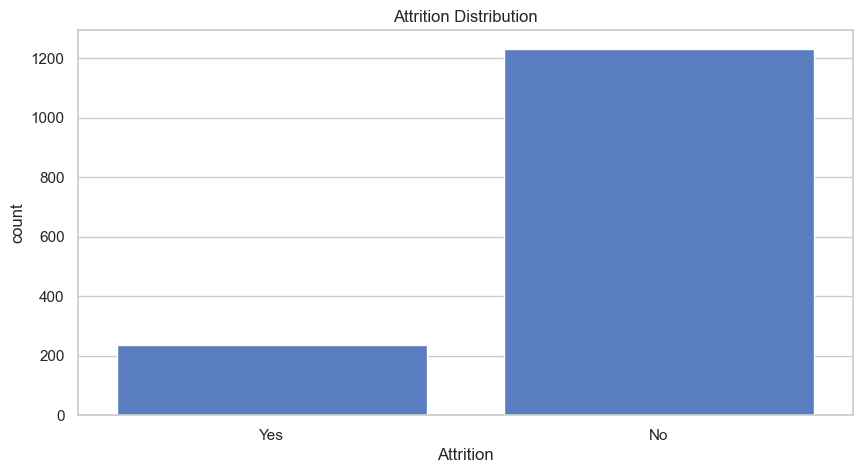

In [136]:
# Plot
sns.countplot(data=df, x='Attrition')
plt.title('Attrition Distribution')
plt.show()

In [137]:
attrition_counts = df['Attrition'].value_counts()
ratio = attrition_counts['No'] / attrition_counts['Yes']
print(f"'No' / 'Yes' oranı: {ratio:.1f}x")
print()
if ratio > 3:
    print("WARNING: Significant class imbalance detected.")
    print("Consider using class_weight='balanced' or SMOTE during modelling.")

'No' / 'Yes' oranı: 5.2x

Consider using class_weight='balanced' or SMOTE during modelling.


Accuracy metriği yanıltıcı olabilir.Artık değişken analizlere geçebiliriz.

In [142]:

num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
num_cols

['Age',
 'DailyRate',
 'DistanceFromHome',
 'Education',
 'EmployeeCount',
 'EmployeeNumber',
 'EnvironmentSatisfaction',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobSatisfaction',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StandardHours',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

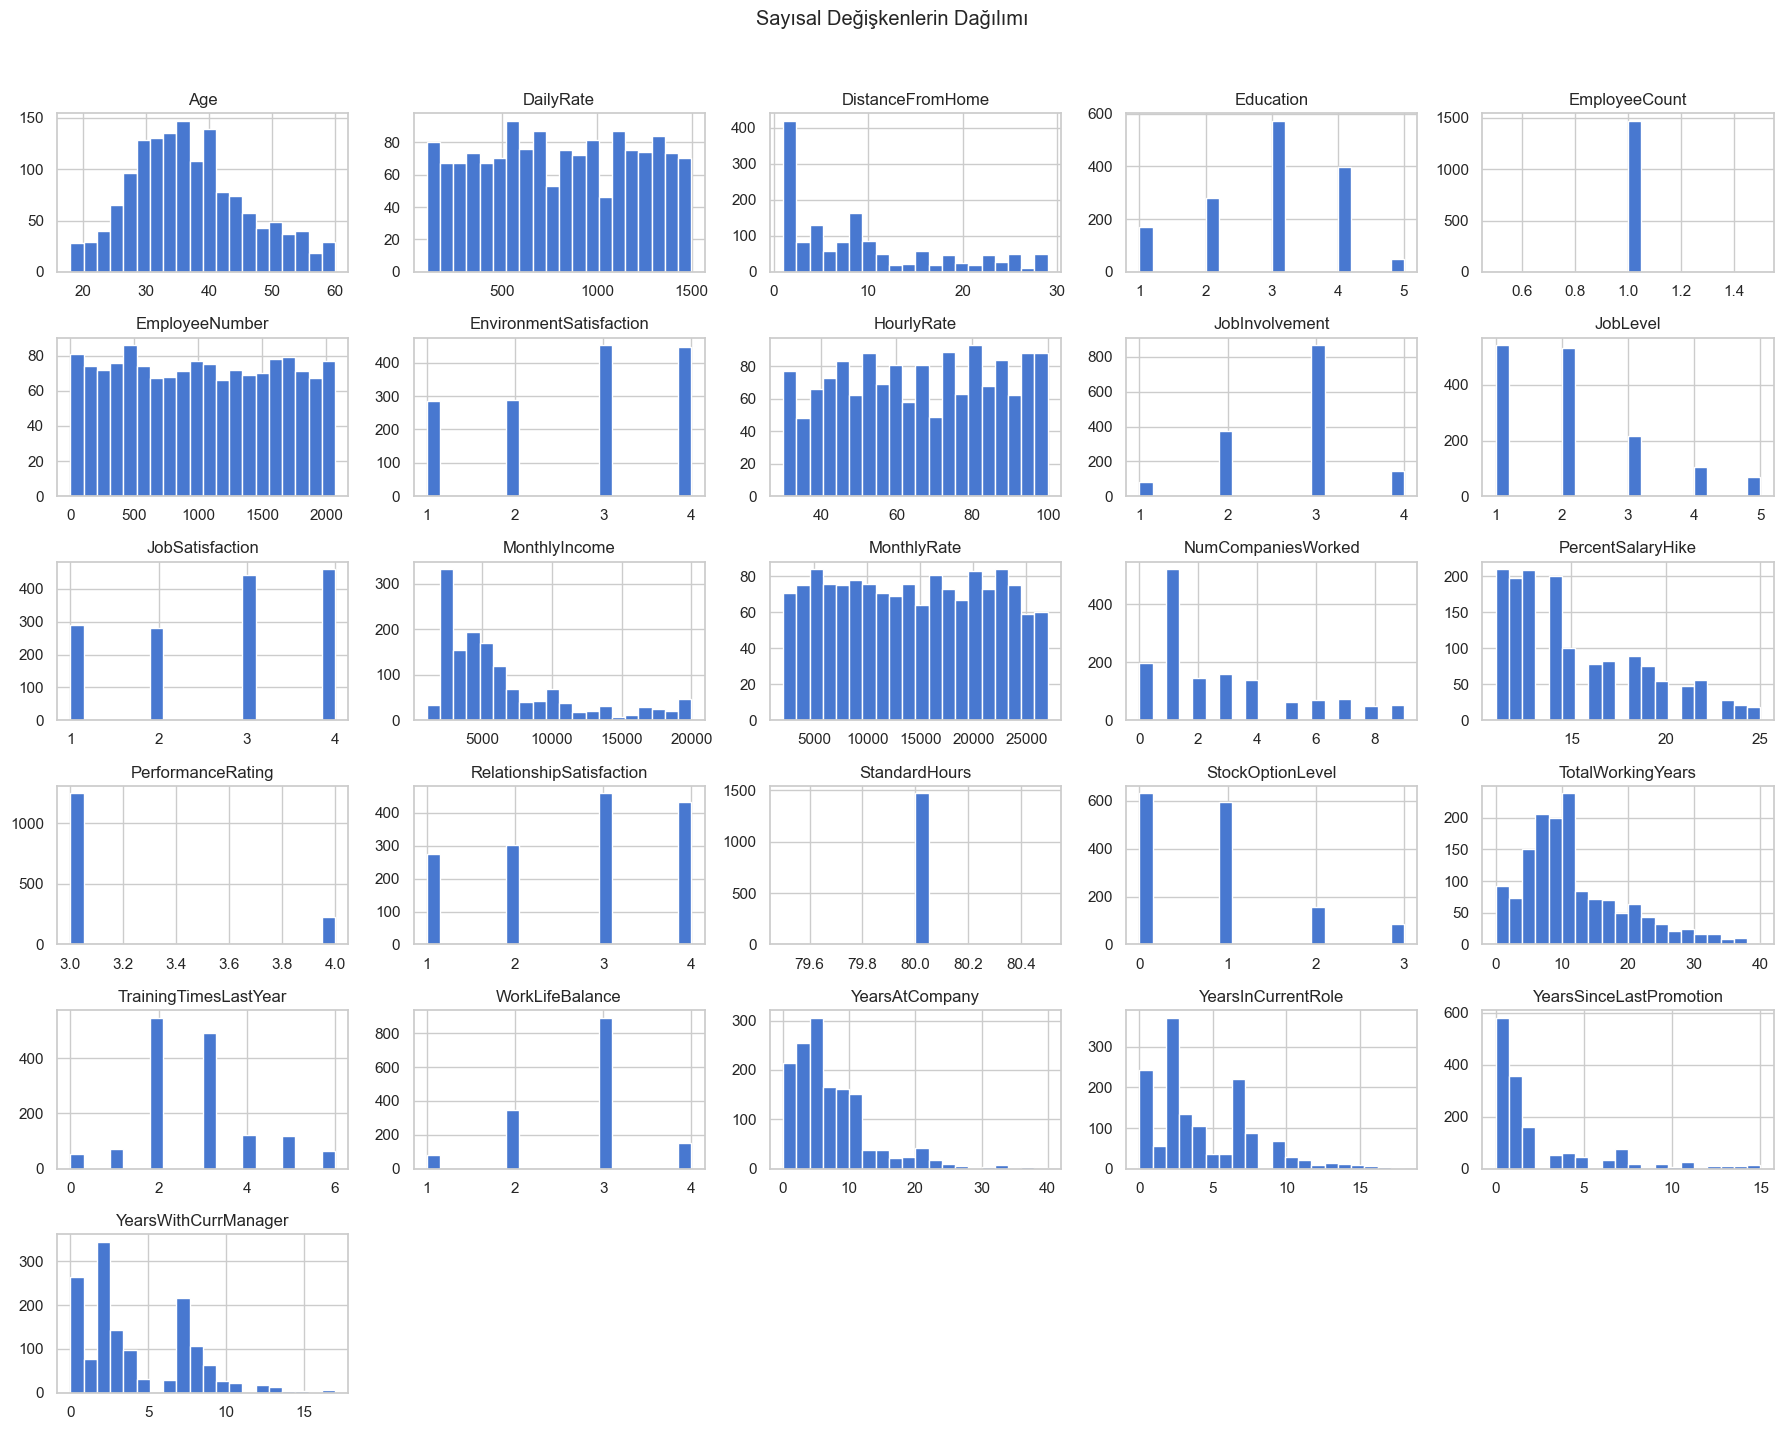

In [143]:
df[num_cols].hist(bins=20, figsize=(18, 14))
plt.suptitle('Sayısal Değişkenlerin Dağılımı', y=1.02)
plt.tight_layout()
plt.show()

In [144]:
df[num_cols].skew().sort_values(ascending=False)

YearsSinceLastPromotion     1.98
PerformanceRating           1.92
YearsAtCompany              1.76
MonthlyIncome               1.37
TotalWorkingYears           1.12
NumCompaniesWorked          1.03
JobLevel                    1.03
StockOptionLevel            0.97
DistanceFromHome            0.96
YearsInCurrentRole          0.92
YearsWithCurrManager        0.83
PercentSalaryHike           0.82
TrainingTimesLastYear       0.55
Age                         0.41
MonthlyRate                 0.02
EmployeeNumber              0.02
StandardHours               0.00
EmployeeCount               0.00
DailyRate                  -0.00
HourlyRate                 -0.03
Education                  -0.29
RelationshipSatisfaction   -0.30
EnvironmentSatisfaction    -0.32
JobSatisfaction            -0.33
JobInvolvement             -0.50
WorkLifeBalance            -0.55
dtype: float64

In [145]:
cat_cols = df.select_dtypes(include=['str']).columns.tolist()
print(cat_cols)

['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


In [146]:
for col in cat_cols:
    print(f"{col}: {df[col].unique()}")

Attrition: <StringArray>
['Yes', 'No']
Length: 2, dtype: str
BusinessTravel: <StringArray>
['Travel_Rarely', 'Travel_Frequently', 'Non-Travel']
Length: 3, dtype: str
Department: <StringArray>
['Sales', 'Research & Development', 'Human Resources']
Length: 3, dtype: str
EducationField: <StringArray>
[   'Life Sciences',            'Other',          'Medical',
        'Marketing', 'Technical Degree',  'Human Resources']
Length: 6, dtype: str
Gender: <StringArray>
['Female', 'Male']
Length: 2, dtype: str
JobRole: <StringArray>
[          'Sales Executive',        'Research Scientist',
     'Laboratory Technician',    'Manufacturing Director',
 'Healthcare Representative',                   'Manager',
      'Sales Representative',         'Research Director',
           'Human Resources']
Length: 9, dtype: str
MaritalStatus: <StringArray>
['Single', 'Married', 'Divorced']
Length: 3, dtype: str
Over18: <StringArray>
['Y']
Length: 1, dtype: str
OverTime: <StringArray>
['Yes', 'No']
Length: 2,

In [81]:
df.groupby('OverTime')["Attrition"].value_counts(normalize=True).mul(100).round(1)

OverTime  Attrition
No        No          89.60
          Yes         10.40
Yes       No          69.50
          Yes         30.50
Name: proportion, dtype: float64

Attrition rate among employees who do not work overtime: 10.4%. Among those who do: 30.5% — nearly 3x higher. OverTime is one of the strongest individual signals in this dataset.

In [82]:
df.groupby("Attrition")["YearsSinceLastPromotion"].mean()

Attrition
No    2.23
Yes   1.95
Name: YearsSinceLastPromotion, dtype: float64

In [83]:
df.groupby('Attrition')['YearsSinceLastPromotion'].median()

Attrition
No    1.00
Yes   1.00
Name: YearsSinceLastPromotion, dtype: float64

Yani yukarıdaki istatistiklere bakarak söyleyebiliriz ki  terfi almama, hedef değişken için tek başına çok önemli bir özellik değil. ama başka önemli özellikler ile bir araya geldiğinde nasıl değiştiğine bakalım.

In [84]:
# YearsSinceLastPromotion'ı gruplara bölelim
df['PromoGroup'] = pd.cut(
    df['YearsSinceLastPromotion'],
    bins=[-1, 0, 2, 5, 100],
    labels=['0 yıl', '1-2 yıl', '3-5 yıl', '5+ yıl']
)

# Her grupta ortalama maaş ve attrition oranı
promo_summary = df.groupby('PromoGroup', observed=True).agg(
    attrition_orani=('Attrition', lambda x: (x == 'Yes').mean() * 100),
    ort_maas=('MonthlyIncome', 'mean'),
    n=('Attrition', 'count')
).round(1)

print(promo_summary)

            attrition_orani  ort_maas    n
PromoGroup                                
0 yıl                 18.90   5499.60  581
1-2 yıl               14.70   5945.70  516
3-5 yıl               10.10   8025.70  158
5+ yıl                16.30   9432.60  215


In [85]:
df.groupby(['PromoGroup', 'OverTime'], observed=True)['Attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100
).round(1).unstack()

OverTime,No,Yes
PromoGroup,,
0 yıl,12.40,34.50
1-2 yıl,9.70,27.60
3-5 yıl,5.90,22.50
5+ yıl,10.30,31.70


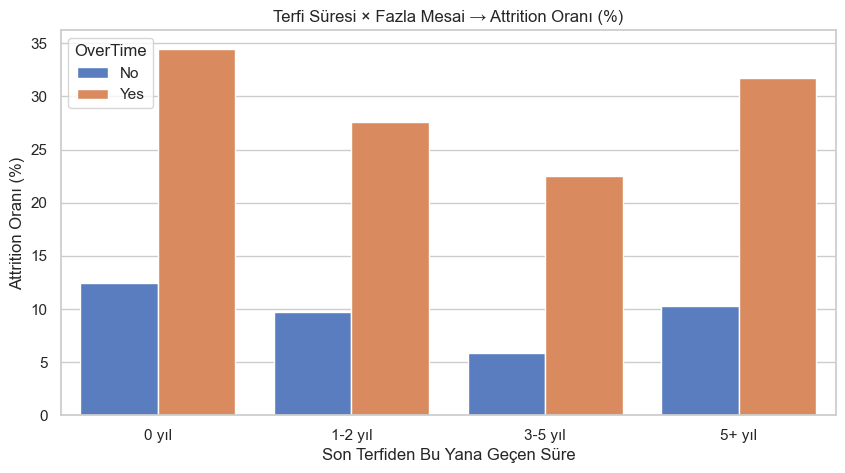

In [86]:
plot_data = df.groupby(['PromoGroup', 'OverTime'], observed=True)['Attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100
).round(1).reset_index()
plot_data.columns = ['PromoGroup', 'OverTime', 'AttritionOrani']

sns.barplot(data=plot_data, x='PromoGroup', y='AttritionOrani', hue='OverTime')
plt.title('Terfi Süresi × Fazla Mesai → Attrition Oranı (%)')
plt.xlabel('Son Terfiden Bu Yana Geçen Süre')
plt.ylabel('Attrition Oranı (%)')
plt.show()

Analiz, OverTime'ın baskın değişken olduğunu ortaya koyuyor.Fazla mesai yapan çalışanlarda attrition oranı terfi süresinden bağımsız olarak yüksek seyrediyor (%22-34). Bununla birlikte "5+ yıl terfi yok + OverTime=Yes" kombinasyonu ikinci en yüksek risk grubunu oluşturuyor (%31). YearsSinceLastPromotion tek başına zayıf bir sinyal olsa da OverTime ile birlikte anlamlı hale geliyor — bu nedenle modelleme aşamasında bu iki değişkenin interaction feature'ı olarak ele alınması düşünülebilir.(fe kısmında OverTime_x_LongNoPromo )

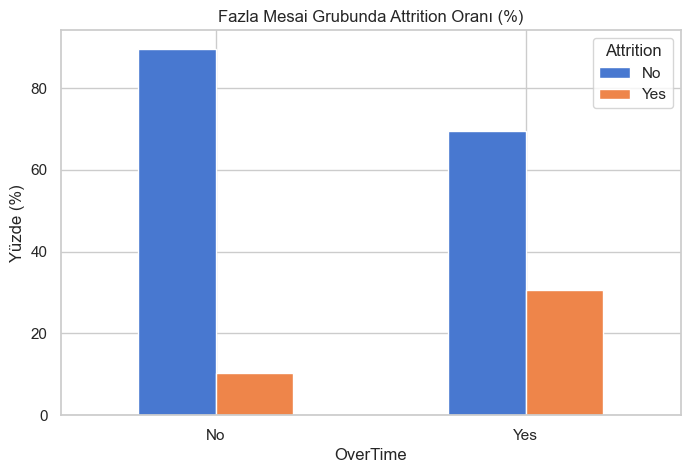

In [87]:
overtime_attrition = df.groupby('OverTime')['Attrition'].value_counts(normalize=True).mul(100).round(1).unstack()

overtime_attrition.plot(kind='bar', figsize=(8, 5))
plt.title('Fazla Mesai Grubunda Attrition Oranı (%)')
plt.xlabel('OverTime')
plt.ylabel('Yüzde (%)')
plt.xticks(rotation=0)
plt.show()

şimdi gelirlere bakmak için MonthlyIncome kolonunu inceleyebiliriz

<Axes: xlabel='MonthlyIncome', ylabel='Density'>

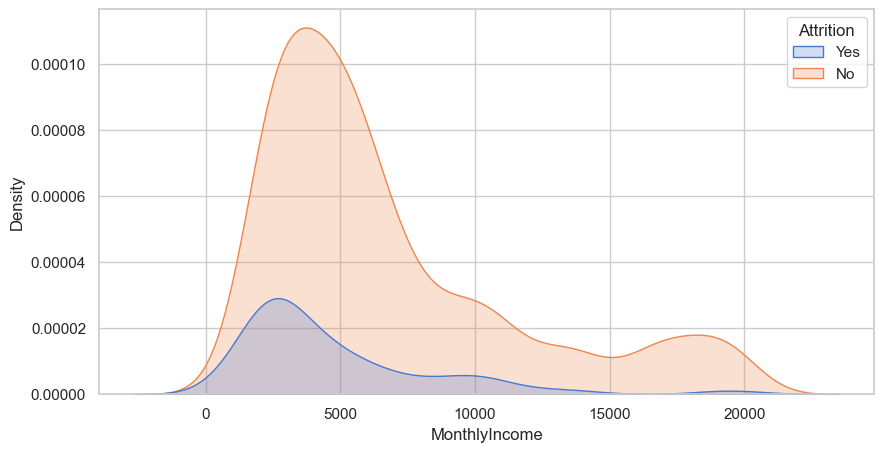

In [88]:
sns.kdeplot(data=df, x="MonthlyIncome", hue="Attrition", fill=True)

In [89]:
df.groupby("Attrition")["MonthlyIncome"].describe()

,count,mean,std,min,25%,50%,75%,max
Attrition,,,,,,,,
No,1233.00,6832.74,4818.21,1051.00,3211.00,5204.00,8834.00,19999.00
Yes,237.00,4787.09,3640.21,1009.00,2373.00,3202.00,5916.00,19859.00


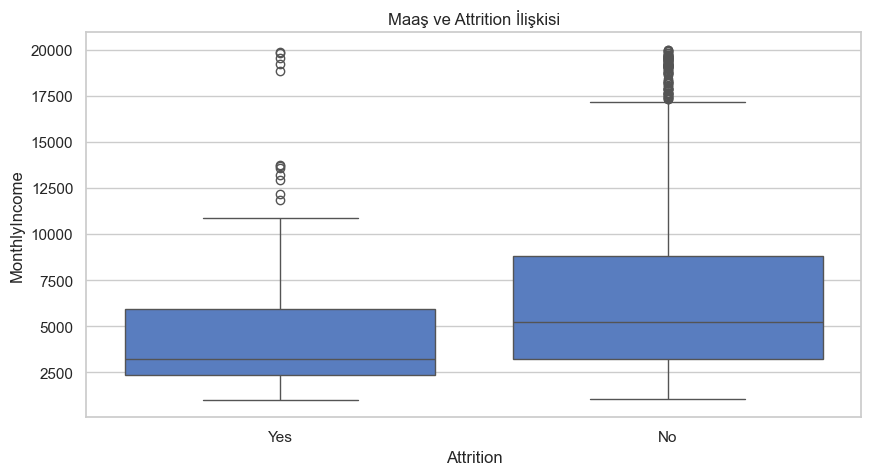

In [90]:
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome')
plt.title('Maaş ve Attrition İlişkisi')
plt.show()

Burda ayrılanların maaşı yaklaşık %30 daha düşük.Bu da güçlü bir ilişki. Ama ayrılanlardan yüksek maaş alanlar da mevcut bu da maaş güçlü bir ilişki de olsa tek başına yeterli olmayabileceğini söylüyor. Yani MonthlyIncome diğer değişkenlerle incelenmeli. Önce maaşı segmentlere ayıralım.

In [91]:
df["IncomeBin"] = pd.qcut(df["MonthlyIncome"], 4)

In [92]:
pd.crosstab([df["IncomeBin"], df["OverTime"]],
            df["Attrition"],
            normalize="index")

Attrition                     No  Yes
IncomeBin          OverTime          
(1008.999, 2911.0] No       0.83 0.17
                   Yes      0.42 0.58
(2911.0, 4919.0]   No       0.90 0.10
                   Yes      0.74 0.26
(4919.0, 8379.0]   No       0.93 0.07
                   Yes      0.81 0.19
(8379.0, 19999.0]  No       0.93 0.07
                   Yes      0.82 0.18

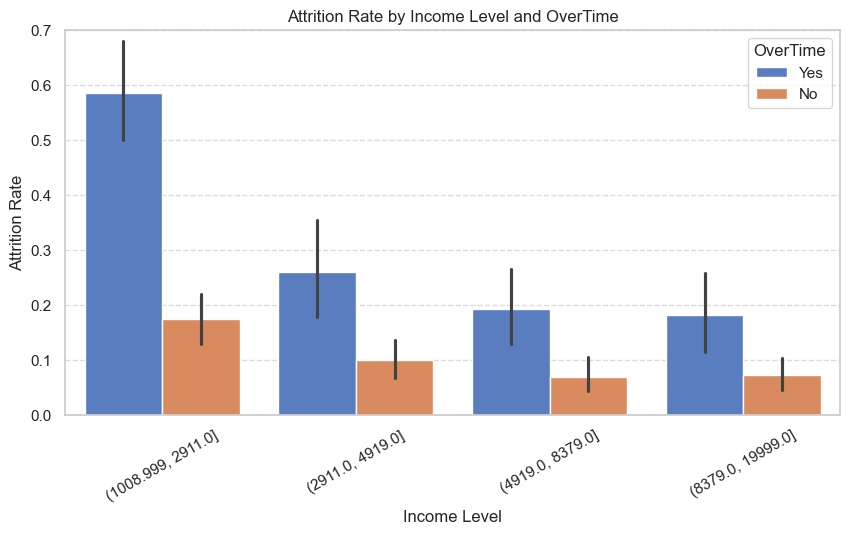

In [93]:
sns.barplot(
    x="IncomeBin",
    y="AttritionFlag",
    hue="OverTime",
    data=df
)

plt.ylim(0, 0.7)  # scale sabitle
plt.title("Attrition Rate by Income Level and OverTime")
plt.ylabel("Attrition Rate")
plt.xlabel("Income Level")
plt.legend(title="OverTime")
plt.xticks(rotation=30)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

Düşük maaş seviyelerinde fazla mesai yapan çalışanların attrition oranı önemli ölçüde artmaktadır (%58).  Bu etki, maaş arttıkça zayıflamaktadır. 
Ayrıca bu durum, maaş ve fazla mesainin birlikte çalışan ayrılmasını açıklayan güçlü bir etkileşim oluşturduğunu göstermektedir.

In [94]:
pd.crosstab([df["IncomeBin"], df["JobRole"]],
            df["Attrition"],
            normalize="index")

Attrition                                      No  Yes
IncomeBin          JobRole                            
(1008.999, 2911.0] Human Resources           0.61 0.39
                   Laboratory Technician     0.71 0.29
                   Research Scientist        0.78 0.22
                   Sales Representative      0.56 0.44
(2911.0, 4919.0]   Healthcare Representative 0.95 0.05
                   Human Resources           0.92 0.08
                   Laboratory Technician     0.80 0.20
                   Manufacturing Director    0.90 0.10
                   Research Scientist        0.89 0.11
                   Sales Executive           0.88 0.12
                   Sales Representative      0.71 0.29
(4919.0, 8379.0]   Healthcare Representative 0.95 0.05
                   Human Resources           1.00 0.00
                   Laboratory Technician     0.88 0.12
                   Manufacturing Director    0.96 0.04
                   Research Scientist        0.93 0.07
                   Sales Executive           0.83 0.17
                   Sales Representative      1.00 0.00
(8379.0, 19999.0]  Healthcare Representative 0.89 0.11
                   Human Resources           0.60 0.40
                   Manager                   0.95 0.05
                   Manufacturing Director    0.91 0.09
                   Research Director         0.97 0.03
                   Research Scientist        1.00 0.00
                   Sales Executive           0.78 0.22

Şimdi de diğer güçlü olabilecek JobSatisfaction ve Age değişkenlerine bakalım

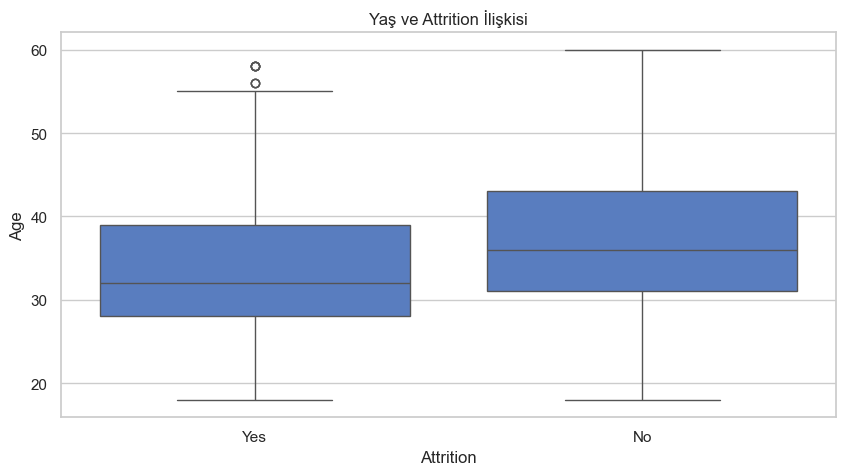

In [95]:
sns.boxplot(data=df, x='Attrition', y='Age')
plt.title('Yaş ve Attrition İlişkisi')
plt.show()

In [96]:
df.groupby("Attrition")["JobSatisfaction"].mean()

Attrition
No    2.78
Yes   2.47
Name: JobSatisfaction, dtype: float64

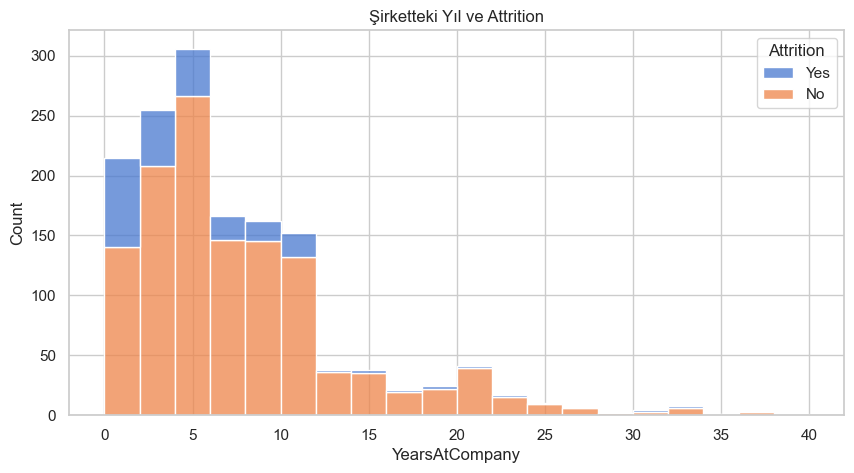

In [97]:
sns.histplot(data=df, x='YearsAtCompany', hue='Attrition', bins=20, multiple='stack')
plt.title('Şirketteki Yıl ve Attrition')
plt.show()

Ham sayı yerine orana da bakalım çünkü gruptaki çalışan sayısı farklı, oran olmadan "çok ayrılma var" derken aslında sadece "çok insan var" demiş olabiliriz.

In [98]:
df['YearsAtCompany_bin'] = pd.cut(df['YearsAtCompany'], bins=[0,2,5,10,20,40], labels=['0-2','3-5','6-10','11-20','20+'])

df.groupby('YearsAtCompany_bin', observed=True)['Attrition'].apply(
    lambda x: (x=='Yes').mean()*100
).round(1)

YearsAtCompany_bin
0-2     28.90
3-5     13.80
6-10    12.30
11-20    6.70
20+     12.10
Name: Attrition, dtype: float64

In [99]:
df.groupby("Attrition")["DistanceFromHome"].mean()

Attrition
No     8.92
Yes   10.63
Name: DistanceFromHome, dtype: float64

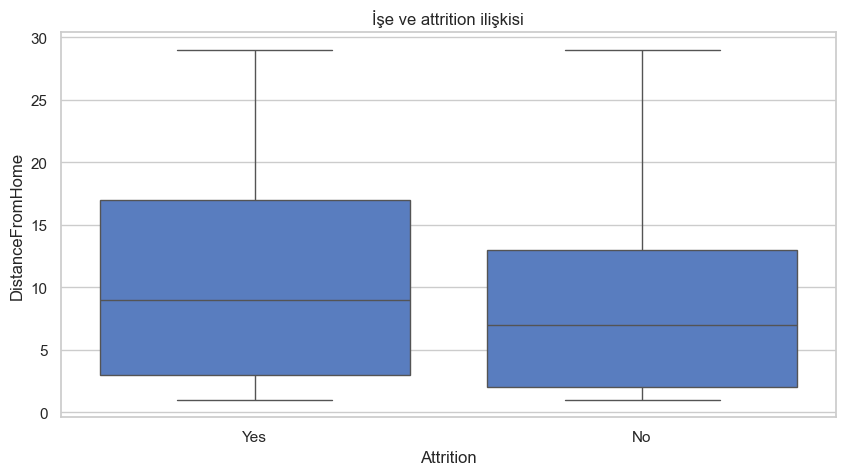

In [100]:
sns.boxplot(data=df,x="Attrition",y="DistanceFromHome")
plt.title("İşe ve attrition ilişkisi")
plt.show()

Tek başına çok güçlü bir sinyal değil ama başka özelliklerle de birleşirse(hem uzak mesafe hem de fazla mesai) güçlü bir sinyal olabilir.

In [101]:
df.groupby('Attrition')[sayisal_sutunlar].mean()

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,AttritionFlag
Attrition,,,,,,,,,,,,,,,,,,,,,,,,
No,37.56,812.50,8.92,2.93,2.77,65.95,2.77,2.15,2.78,6832.74,14265.78,2.65,15.23,3.15,2.73,0.85,11.86,2.83,2.78,7.37,4.48,2.23,4.37,0.00
Yes,33.61,750.36,10.63,2.84,2.46,65.57,2.52,1.64,2.47,4787.09,14559.31,2.94,15.10,3.16,2.60,0.53,8.24,2.62,2.66,5.13,2.90,1.95,2.85,1.00


Analiz, işten ayrılan çalışanların daha düşük hisse senedi opsiyonu seviyesine, daha az toplam iş deneyimine ve şirketteki ile mevcut rolündeki daha kısa kıdeme sahip olduğunu ortaya koymaktadır. Bu bulgular, şirkete henüz tam anlamıyla entegre olamamış çalışanların ayrılma riskinin daha yüksek olduğuna işaret etmektedir.

In [102]:
df.groupby("JobLevel")["Attrition"].value_counts(normalize=True).mul(100).round(1).unstack()

Attrition,No,Yes
JobLevel,,
1,73.70,26.30
2,90.30,9.70
3,85.30,14.70
4,95.30,4.70
5,92.80,7.20


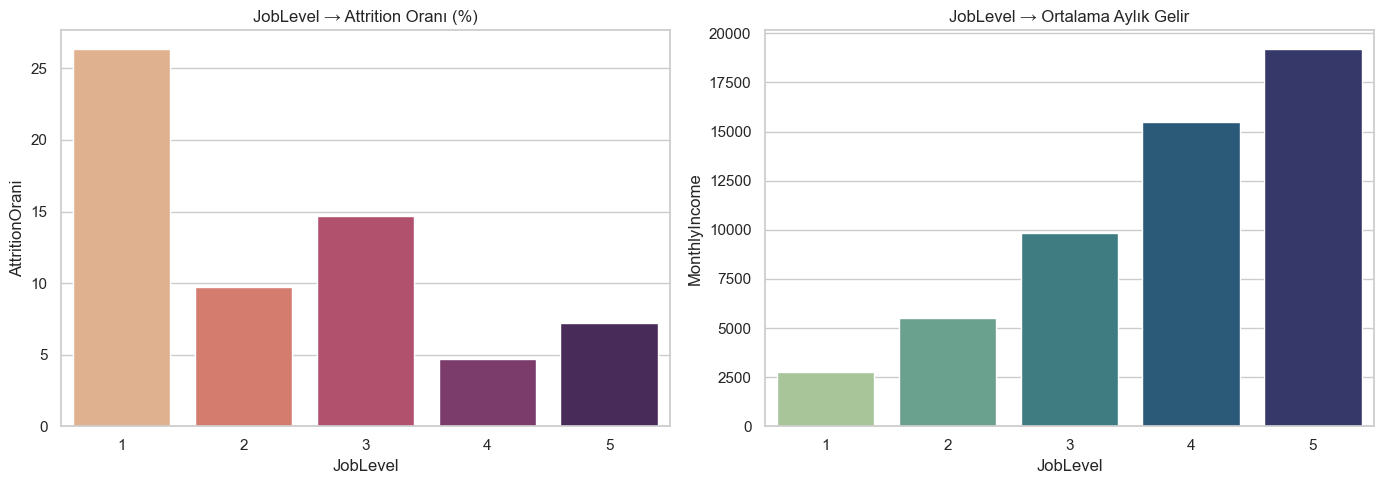

In [103]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

attrition_rate = (
    df.groupby("JobLevel")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="AttritionOrani")
)
sns.barplot(data=attrition_rate, x="JobLevel", y="AttritionOrani",
            hue="JobLevel", palette="flare", legend=False, ax=axes[0])
axes[0].set_title("JobLevel → Attrition Oranı (%)")

income_by_level = df.groupby("JobLevel")["MonthlyIncome"].mean().reset_index()
sns.barplot(data=income_by_level, x="JobLevel", y="MonthlyIncome",
            hue="JobLevel", palette="crest", legend=False, ax=axes[1])
axes[1].set_title("JobLevel → Ortalama Aylık Gelir")

plt.tight_layout()
plt.show()

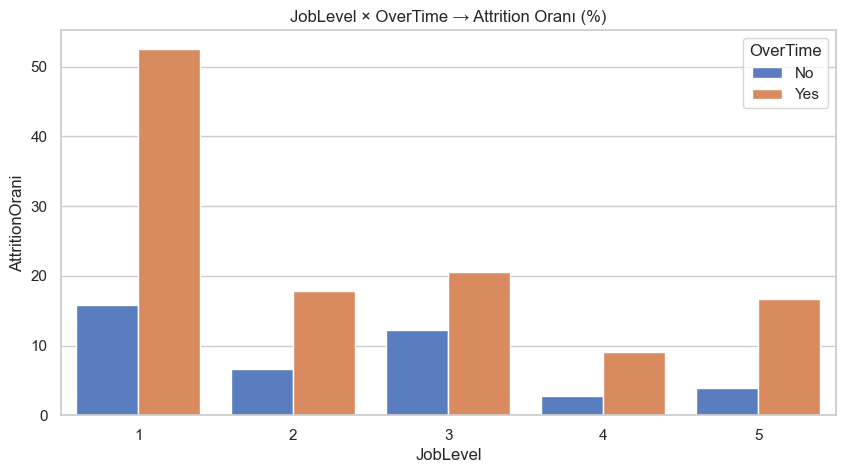

In [104]:
jl_ot_plot = (
    df.groupby(["JobLevel", "OverTime"])["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .round(1).reset_index(name="AttritionOrani")
)
sns.barplot(data=jl_ot_plot, x="JobLevel", y="AttritionOrani", hue="OverTime", palette="muted")
plt.title("JobLevel × OverTime → Attrition Oranı (%)")
plt.show()

JobLevel × OverTime kombinasyonu, EDA'nın en güçlü bulgularından birini ortaya koyuyor: Level 1 + OverTime=Yes grubunda attrition oranı %52'ye ulaşıyor.
Level arttıkça bu etki belirgin şekilde zayıflıyor (Level 4: %9, Level 5: %17).

Bu bulgu, feature engineering aşamasında `JobLevel_x_OverTime` interaction feature'ının oluşturulmasını desteklemektedir — özellikle düşük seviyeli ve fazla mesai yapan çalışanları hedefleyen bir risk skoru için güçlü bir sinyal sağlayabilir.

artık kategorik değişkenlere geçebiliriz

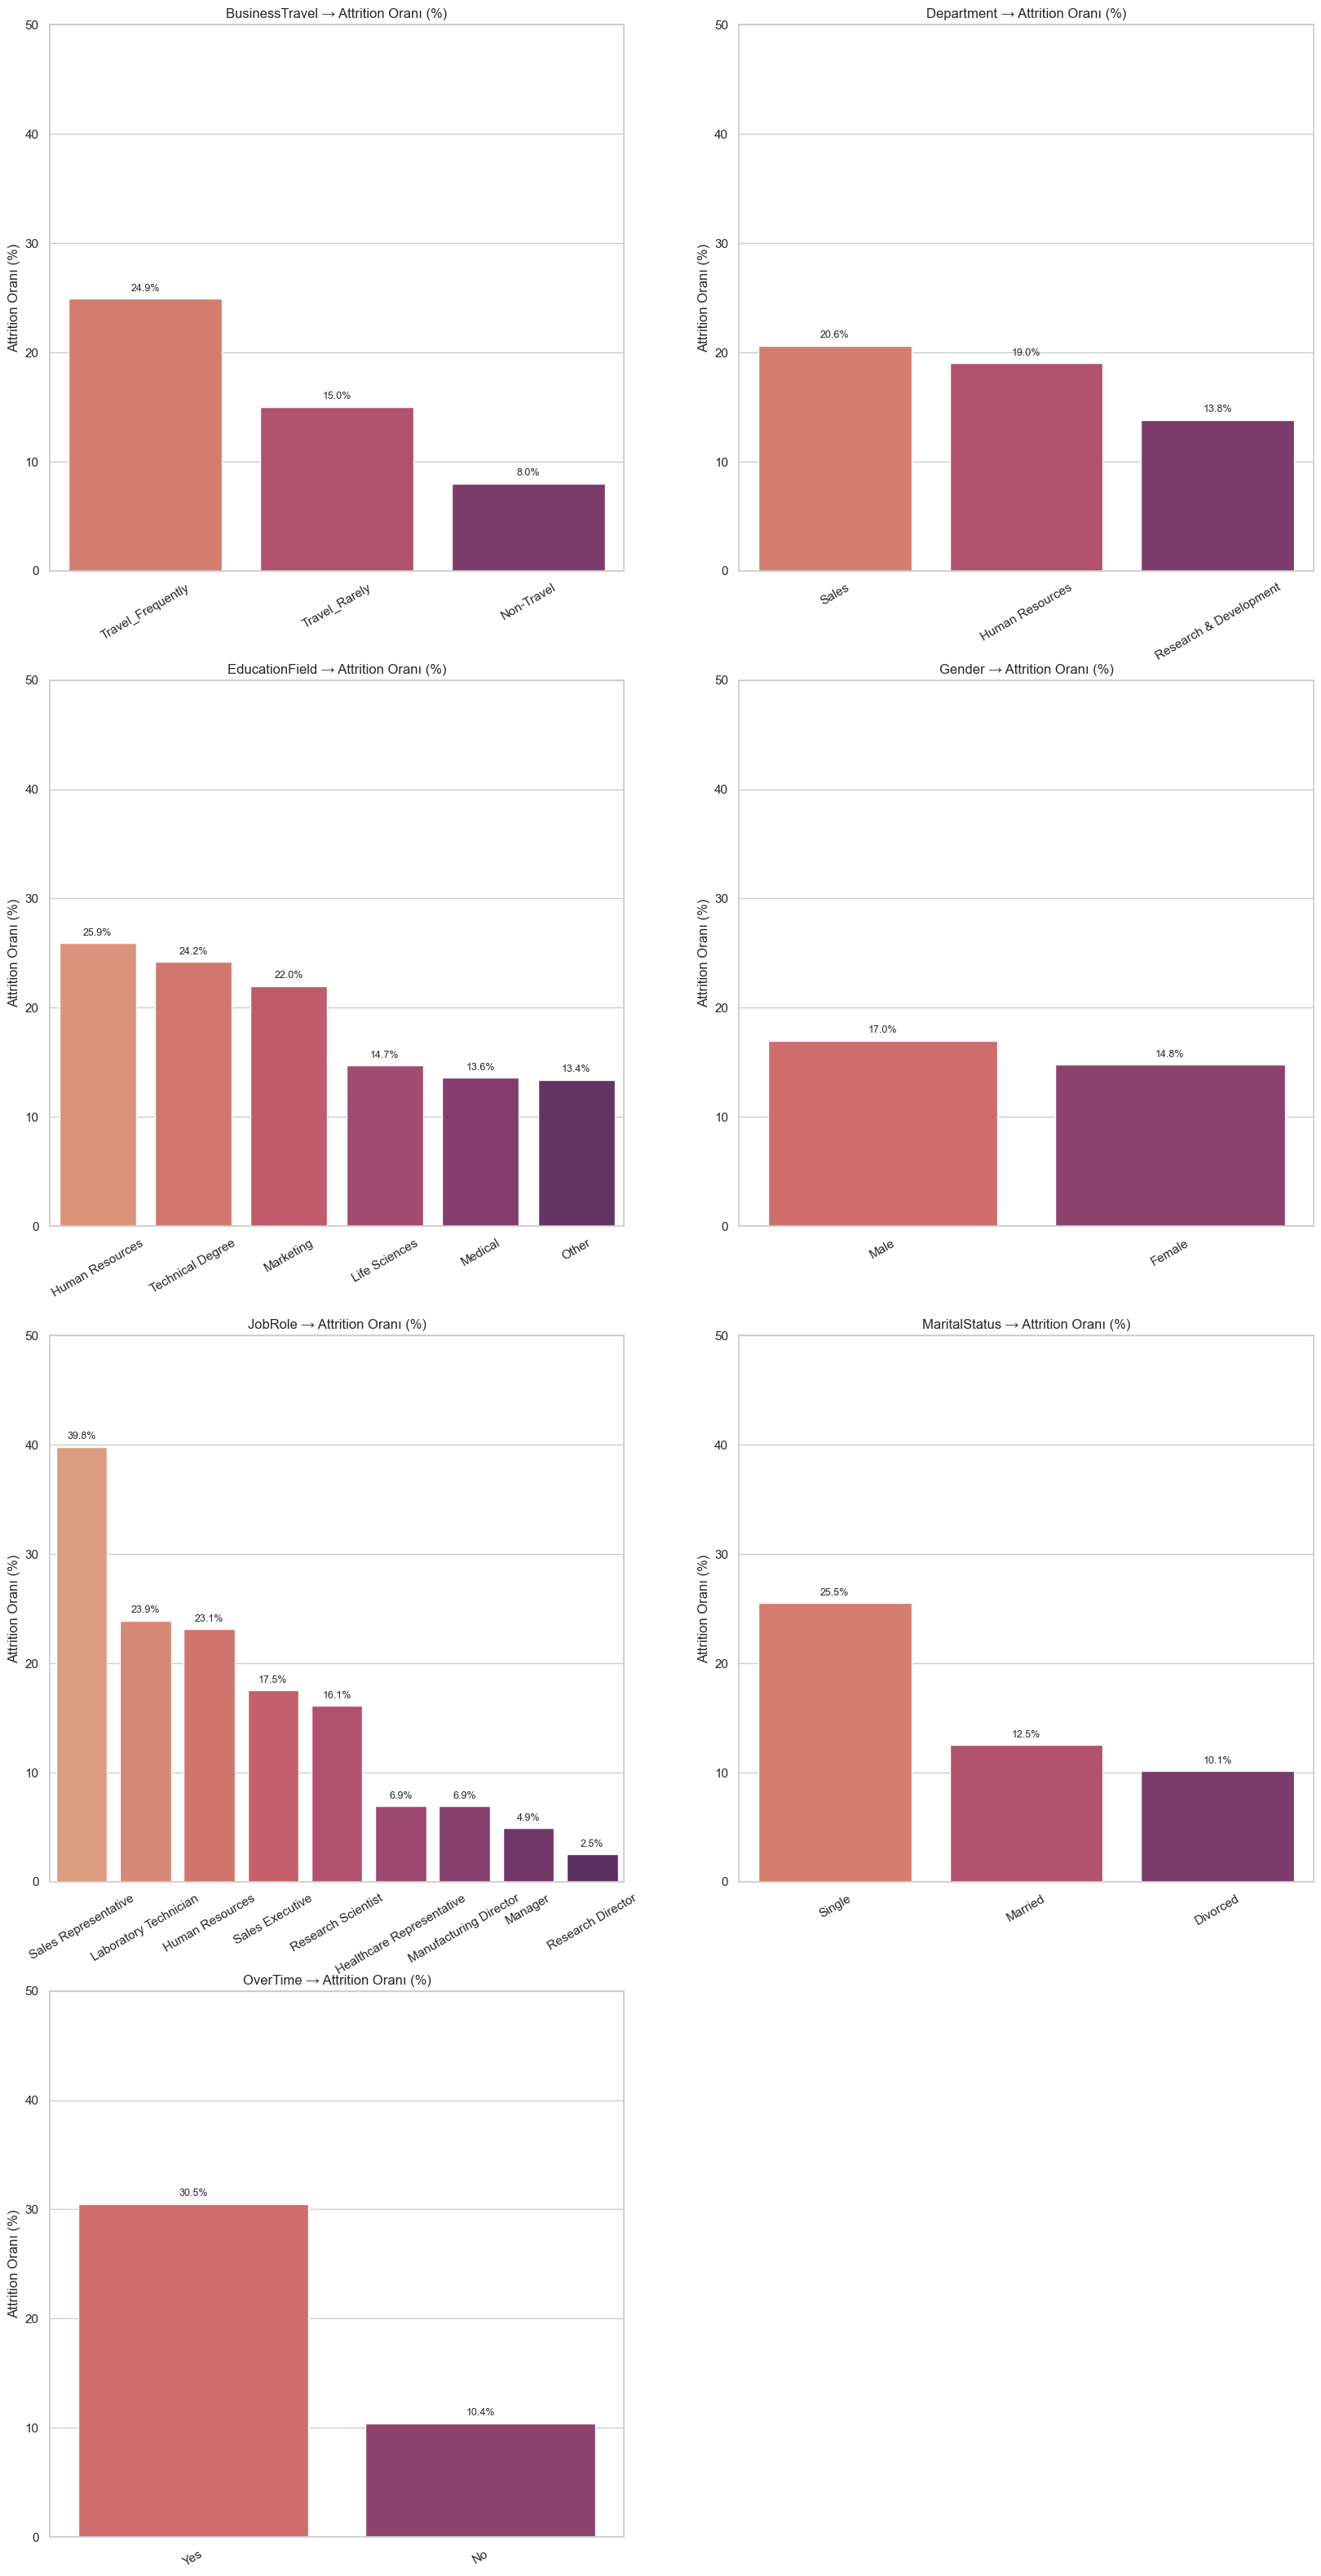

In [105]:
kategorik_sutunlar_viz = ['BusinessTravel', 'Department', 'EducationField', 
                           'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

fig, axes = plt.subplots(4, 2, figsize=(20, 40))
axes = axes.flatten()

for i, col in enumerate(kategorik_sutunlar_viz):
    rate = (
        df.groupby(col)['Attrition']
        .apply(lambda x: (x == 'Yes').mean() * 100)
        .round(1)
        .reset_index(name='AttritionOrani')
        .sort_values('AttritionOrani', ascending=False)
    )
    sns.barplot(data=rate, x=col, y='AttritionOrani',
                hue=col, palette='flare', legend=False, ax=axes[i])
    axes[i].set_title(f'{col} → Attrition Oranı (%)')
    axes[i].set_ylabel('Attrition Oranı (%)')
    axes[i].set_xlabel('')
    axes[i].set_ylim(0, 50)
    axes[i].tick_params(axis='x', rotation=30)
    
    # her barın üstüne yüzde yaz
    for bar in axes[i].patches:
        h = bar.get_height()
        if h > 0:
            axes[i].text(bar.get_x() + bar.get_width()/2, h + 0.5,
                         f'{h:.1f}%', ha='center', va='bottom', fontsize=9)

axes[-1].set_visible(False)  # 8

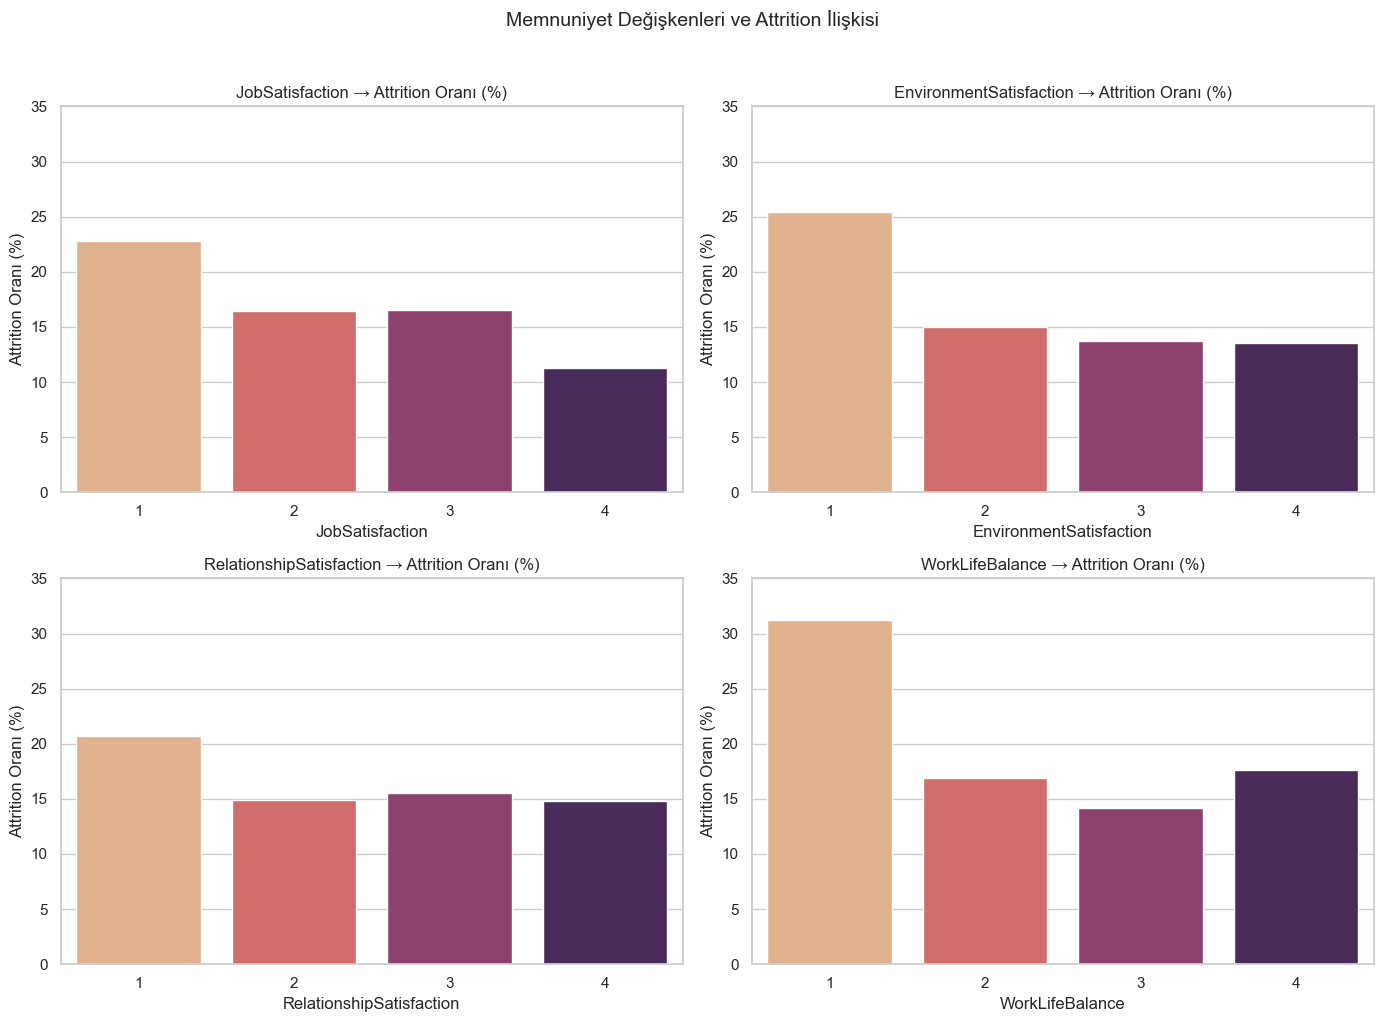

In [106]:
sat_cols = ['JobSatisfaction', 'EnvironmentSatisfaction', 'RelationshipSatisfaction', 'WorkLifeBalance']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(sat_cols):
    rate = (
        df.groupby(col)['Attrition']
        .apply(lambda x: (x == 'Yes').mean() * 100)
        .round(1)
        .reset_index(name='AttritionOrani')
    )
    sns.barplot(data=rate, x=col, y='AttritionOrani',
                hue=col, palette='flare', legend=False, ax=axes[i])
    axes[i].set_title(f'{col} → Attrition Oranı (%)')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Attrition Oranı (%)')
    axes[i].set_ylim(0, 35)

plt.suptitle('Memnuniyet Değişkenleri ve Attrition İlişkisi', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [107]:
df.groupby("Department")["Attrition"].value_counts(normalize=True).mul(100).round(1).unstack()

Attrition,No,Yes
Department,,
Human Resources,81.00,19.00
Research & Development,86.20,13.80
Sales,79.40,20.60


R&D departmanlarında görece daha az işten çıkma söz konusu

In [108]:
df.groupby("JobRole")["Attrition"].value_counts(normalize=True).mul(100).round(1).unstack()


Attrition,No,Yes
JobRole,,
Healthcare Representative,93.10,6.90
Human Resources,76.90,23.10
Laboratory Technician,76.10,23.90
Manager,95.10,4.90
Manufacturing Director,93.10,6.90
Research Director,97.50,2.50
Research Scientist,83.90,16.10
Sales Executive,82.50,17.50
Sales Representative,60.20,39.80


Görüldüğü üzere düşük seviyedeki işler işten çıkmaya daha meyilli. Bunu görselleştirelim

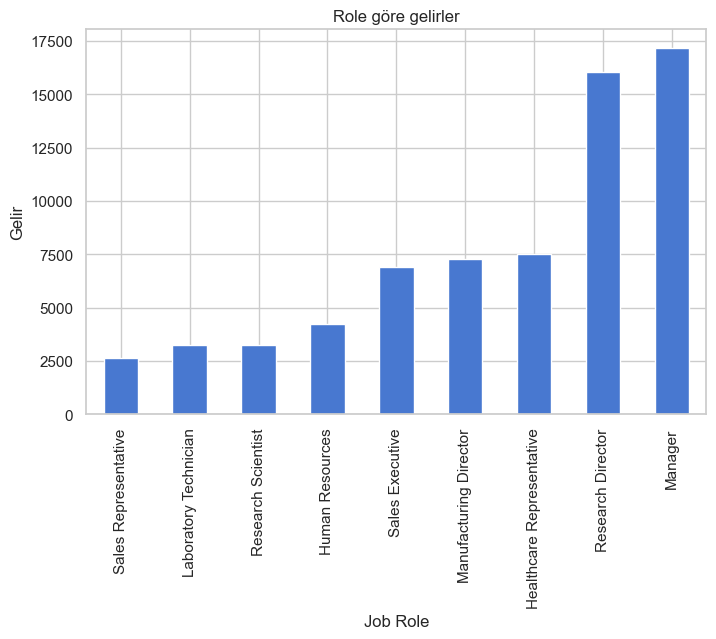

In [109]:
jobrole_income = df.groupby('JobRole')['MonthlyIncome'].mean().sort_values()
jobrole_income.plot(kind='bar',figsize=(8, 5))
plt.title('Role göre gelirler')
plt.xlabel('Job Role')
plt.ylabel('Gelir')
plt.show()

Aslında bu grafik daha önce bulduğumuz 2 şeyi birleştiriyor; düşük maaş ve düşük seviye iş birleştiğinde yüksek ayrılma oranına sahip oluyor.

In [110]:
df.groupby("BusinessTravel")["Attrition"].value_counts(normalize=True).mul(100).round(1).unstack()

Attrition,No,Yes
BusinessTravel,,
Non-Travel,92.00,8.00
Travel_Frequently,75.10,24.90
Travel_Rarely,85.00,15.00


In [111]:
df.groupby("Gender")["Attrition"].value_counts(normalize=True).mul(100).round(1).unstack()

Attrition,No,Yes
Gender,,
Female,85.20,14.80
Male,83.00,17.00


Diğer 2 kategorik değişkene baktığımızda sık seyahat edenlerin işi bırakma ihtimali, hiç seyahet etmeyenlerin neredeyse 3 katı. Ama cinsiyete baktığımızda önemli bir fark gözlemkenmiyor. Artık bu noktadan sonra korelasyona bakmaya başlayabiliriz

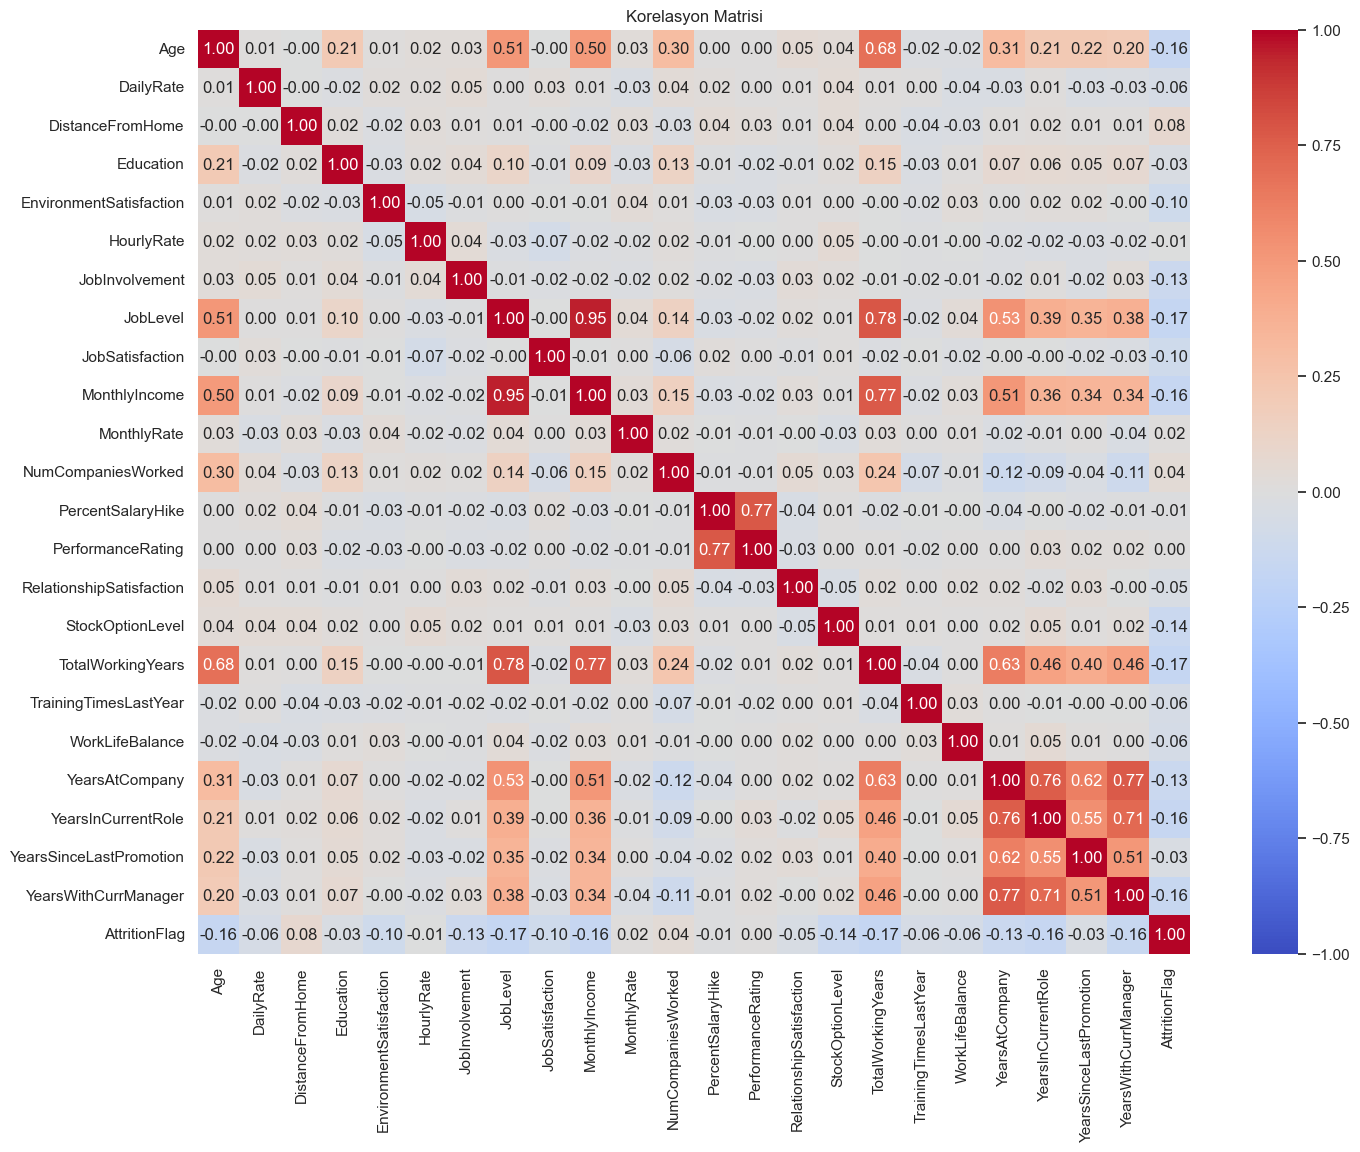

In [112]:
corr_matrix = df[sayisal_sutunlar].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm',
            center=0,
            vmin=-1, vmax=1)
plt.title('Korelasyon Matrisi')
plt.show()

Korelasyon matrisi incelendiğinde, bazı değişkenler arasında güçlü korelasyon kümeleri olduğu görülmektedir. Özellikle MonthlyIncome, JobLevel ve TotalWorkingYears değişkenleri benzer bilgiyi temsil eden bir grup oluştururken,YearsAtCompany, YearsInCurrentRole ve YearsWithCurrManager değişkenleri de çalışanların organizasyon içindeki kıdemini temsil etmektedir.

Bu durum, modelleme aşamasında çoklu doğrusal bağlantı (multicollinearity) riskine işaret etmektedir.Buna karşın, DistanceFromHome ve bazı ücret bazlı değişkenlerin diğerlerinden bağımsız olduğu gözlemlenmiştir.

In [134]:
corr_matrix = df[sayisal_sutunlar + ["AttritionFlag"]].corr()
corr_matrix["AttritionFlag"].sort_values(ascending=False)

KeyError: "['AttritionFlag'] not in index"

Sayısal değişkenlerin Attrition ile olan korelasyonları oldukça düşüktür 
(|corr|<0.22).  Bu durum, çalışan ayrılmasının tek bir sayısal değişken tarafından açıklanamadığını göstermektedir. Buna karşın, deneyim ve kıdem ile ilişkili değişkenlerin (JobLevel, TotalWorkingYears, MonthlyIncome, Age) negatif korelasyona sahip olması, daha deneyimli çalışanların organizasyonda kalma eğiliminde olduğunu göstermektedir.
Bu bulgular, attrition probleminin lineer ilişkilerden ziyade değişkenler arası etkileşimler ve kategorik faktörler ile açıklanabileceğini göstermektedir.Artık EDA'ya göre feature engineering tarafına geçebiliriz

In [154]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import roc_auc_score, precision_recall_curve, classification_report
import numpy as np


# ── 1. Feature set (ham veri — dışarıda hiçbir transform yok)
X = df.drop(columns=['Attrition'])
y = (df['Attrition'] == 'Yes').astype(int)

# ── 2. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── 3. Custom transformer: HighRisk_Flag + log(MonthlyIncome)
class RiskFeatureAdder(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.income_q1_ = X["MonthlyIncome"].quantile(0.25)  # sadece train'den öğrenir
        return self

    def transform(self, X):
        X = X.copy()
        X["MonthlyIncome_log"] = np.log1p(X["MonthlyIncome"])
        X["HighRisk_Flag"] = (
            (X["OverTime"] == "Yes") &
            (X["JobLevel"] <= 2) &
            (X["MonthlyIncome"] < self.income_q1_)
        ).astype(int)
        return X.drop(columns=["MonthlyIncome"])  # ham income çıkar

# ── 4. Column groups
ordinal_cols  = ['BusinessTravel']
ordinal_order = [['Non-Travel', 'Travel_Rarely', 'Travel_Frequently']]
nominal_cols  = ['Department', 'JobRole', 'MaritalStatus', 'EducationField', 'Gender', 'OverTime']
numeric_cols  = [
    'Age', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction',
    'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome_log',
    'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating',
    'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears',
    'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany',
    'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager',
    'HighRisk_Flag'
]

# ── 5. Preprocessor
preprocessor = ColumnTransformer(transformers=[
    ('ordinal', OrdinalEncoder(categories=ordinal_order), ordinal_cols),
    ('nominal', OneHotEncoder(drop='first', handle_unknown='ignore'), nominal_cols),
    ('numeric', StandardScaler(), numeric_cols),
])

# ── 6. Pipeline
pipeline_v2 = Pipeline(steps=[
    ('feature_engineering', RiskFeatureAdder()),
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

# ── 7. Fit
pipeline_v2.fit(X_train, y_train)

# ── 8. ROC-AUC
y_train_prob = pipeline_v2.predict_proba(X_train)[:, 1]
y_test_prob  = pipeline_v2.predict_proba(X_test)[:, 1]
print("Train ROC-AUC:", roc_auc_score(y_train, y_train_prob))
print("Test  ROC-AUC:", roc_auc_score(y_test,  y_test_prob))

# ── 9. Threshold optimizasyonu — CV üzerinden (test leak yok)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
val_probs, val_labels = [], []

for train_idx, val_idx in skf.split(X_train, y_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    pipeline_v2.fit(X_tr, y_tr)
    val_probs.extend(pipeline_v2.predict_proba(X_val)[:, 1])
    val_labels.extend(y_val)

precisions, recalls, thresholds = precision_recall_curve(val_labels, val_probs)
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-8)
best_threshold = thresholds[np.argmax(f1_scores)]
print(f"\nOptimal threshold (CV): {best_threshold:.3f}")

# ── 10. Final model — tüm train ile yeniden fit et, test'te raporla
pipeline_v2.fit(X_train, y_train)
y_pred_opt = (pipeline_v2.predict_proba(X_test)[:, 1] >= best_threshold).astype(int)
print(classification_report(y_test, y_pred_opt))

Train ROC-AUC: 0.8784242553645778
Test  ROC-AUC: 0.8228098888793177

Optimal threshold (CV): 0.682
              precision    recall  f1-score   support

           0       0.91      0.93      0.92       247
           1       0.60      0.53      0.56        47

    accuracy                           0.87       294
   macro avg       0.75      0.73      0.74       294
weighted avg       0.86      0.87      0.86       294



In [125]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

from sklearn.model_selection import RandomizedSearchCV
import scipy.stats as stats

param_dist = {
    'model__max_depth':        [2, 3, 4],
    'model__n_estimators':     [100, 200, 300],
    'model__learning_rate':    [0.01, 0.03, 0.05, 0.1],
    'model__subsample':        [0.6, 0.7, 0.8],
    'model__colsample_bytree': [0.6, 0.7, 0.8],
    'model__reg_alpha':        [0, 0.1, 0.5, 1.0],
    'model__reg_lambda':       [1.0, 2.0, 3.0],
    'model__min_child_weight': [1, 3, 5],
    'model__gamma':            [0, 0.5, 1.0],
}

pipeline_xgb_search = Pipeline(steps=[
    ('feature_engineering', RiskFeatureAdder()),
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        eval_metric='logloss',
        random_state=42,
        scale_pos_weight=5,
    ))
])

search = RandomizedSearchCV(
    pipeline_xgb_search,
    param_distributions=param_dist,
    n_iter=50,                    # 50 rastgele kombinasyon dene
    scoring='roc_auc',
    cv=5,
    random_state=42,
    n_jobs=-1,                    # tüm CPU'ları kullan
    verbose=1
)

search.fit(X_train, y_train)

print("Best params:", search.best_params_)
print("Best CV AUC:", search.best_score_)

# Test seti sonucu
y_test_prob = search.best_estimator_.predict_proba(X_test)[:, 1]
print("Test  AUC:  ", roc_auc_score(y_test, y_test_prob))

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best params: {'model__subsample': 0.6, 'model__reg_lambda': 2.0, 'model__reg_alpha': 0.5, 'model__n_estimators': 200, 'model__min_child_weight': 3, 'model__max_depth': 3, 'model__learning_rate': 0.05, 'model__gamma': 0, 'model__colsample_bytree': 0.6}
Best CV AUC: 0.8221922673164993
Test  AUC:   0.8174692049272116


In [126]:
# En iyi parametrelerle final pipeline
pipeline_xgb_final = search.best_estimator_

# Threshold optimizasyonu — CV üzerinden (LR'daki gibi)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
val_probs, val_labels = [], []

for train_idx, val_idx in skf.split(X_train, y_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    pipeline_xgb_final.fit(X_tr, y_tr)
    val_probs.extend(pipeline_xgb_final.predict_proba(X_val)[:, 1])
    val_labels.extend(y_val)

precisions, recalls, thresholds = precision_recall_curve(val_labels, val_probs)
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-8)
best_threshold = thresholds[np.argmax(f1_scores)]
print(f"Optimal threshold (CV): {best_threshold:.3f}")

# Final model — tüm train ile yeniden fit et
pipeline_xgb_final.fit(X_train, y_train)
y_pred_opt = (pipeline_xgb_final.predict_proba(X_test)[:, 1] >= best_threshold).astype(int)
print(classification_report(y_test, y_pred_opt))

Optimal threshold (CV): 0.577
              precision    recall  f1-score   support

           0       0.91      0.91      0.91       247
           1       0.53      0.53      0.53        47

    accuracy                           0.85       294
   macro avg       0.72      0.72      0.72       294
weighted avg       0.85      0.85      0.85       294



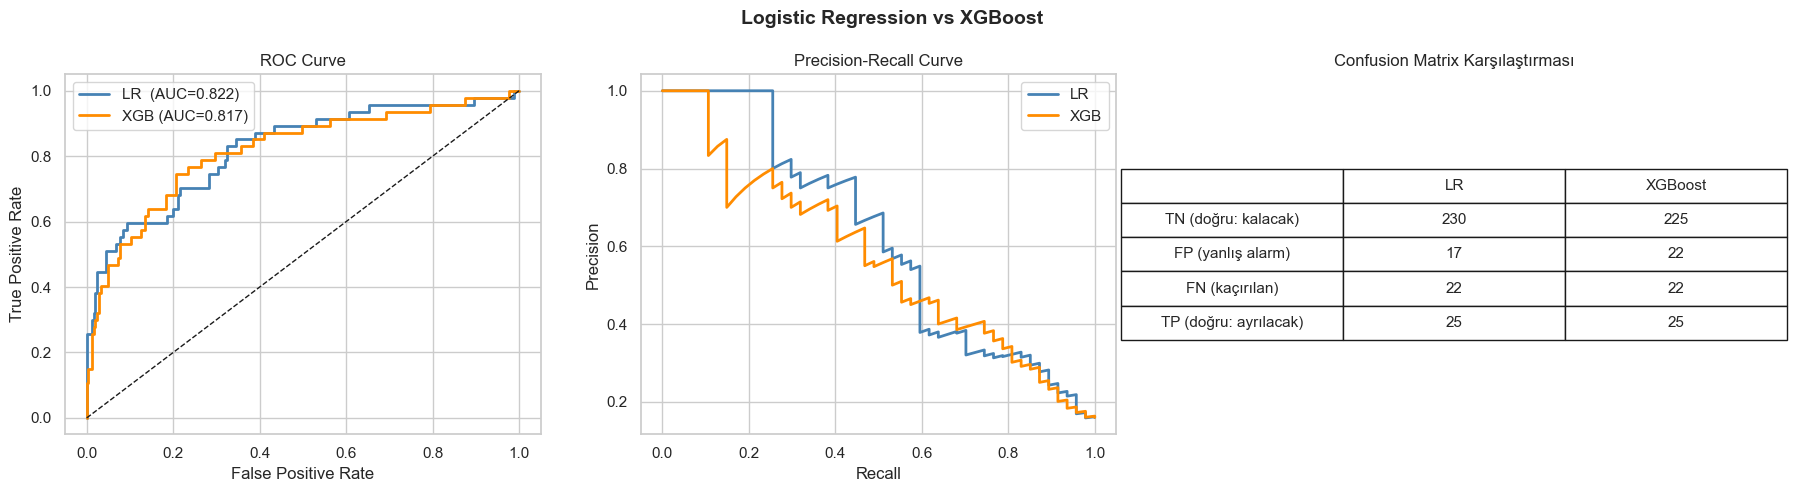

In [133]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, confusion_matrix
import numpy as np

# ── Eşik ile tahminler
lr_threshold  = 0.682
xgb_threshold = 0.577

y_pred_lr  = (y_test_prob_lr  >= lr_threshold).astype(int)
y_pred_xgb = (y_test_prob_xgb >= xgb_threshold).astype(int)

# ── ROC curve verileri
fpr_lr,  tpr_lr,  _ = roc_curve(y_test, y_test_prob_lr)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_test_prob_xgb)

# ── PR curve verileri
prec_lr,  rec_lr,  _ = precision_recall_curve(y_test, y_test_prob_lr)
prec_xgb, rec_xgb, _ = precision_recall_curve(y_test, y_test_prob_xgb)

# ── Confusion matrix verileri
cm_lr  = confusion_matrix(y_test, y_pred_lr)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

# ── Grafik
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Logistic Regression vs XGBoost", fontsize=14, fontweight='bold')

# 1) ROC Curve
ax = axes[0]
ax.plot(fpr_lr,  tpr_lr,  label='LR  (AUC=0.822)', color='steelblue', lw=2)
ax.plot(fpr_xgb, tpr_xgb, label='XGB (AUC=0.817)', color='darkorange', lw=2)
ax.plot([0,1],[0,1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend()

# 2) PR Curve
ax = axes[1]
ax.plot(rec_lr,  prec_lr,  label='LR',  color='steelblue', lw=2)
ax.plot(rec_xgb, prec_xgb, label='XGB', color='darkorange', lw=2)
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve')
ax.legend()

# 3) Confusion Matrix (yan yana)
ax = axes[2]
ax.axis('off')

# Her iki CM'i tablo olarak göster
labels = ['TN', 'FP', 'FN', 'TP']
lr_vals  = cm_lr.ravel()
xgb_vals = cm_xgb.ravel()

table_data = [
    ['', 'LR', 'XGBoost'],
    ['TN (doğru: kalacak)', lr_vals[0], xgb_vals[0]],
    ['FP (yanlış alarm)',   lr_vals[1], xgb_vals[1]],
    ['FN (kaçırılan)',      lr_vals[2], xgb_vals[2]],
    ['TP (doğru: ayrılacak)', lr_vals[3], xgb_vals[3]],
]

table = ax.table(cellText=table_data[1:], colLabels=table_data[0],
                 loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.4, 2.2)
ax.set_title('Confusion Matrix Karşılaştırması')

plt.tight_layout()
plt.savefig('lr_vs_xgb.png', dpi=150, bbox_inches='tight')
plt.show()

/Users/ulasmerttoy/Desktop/machine learning projects/env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


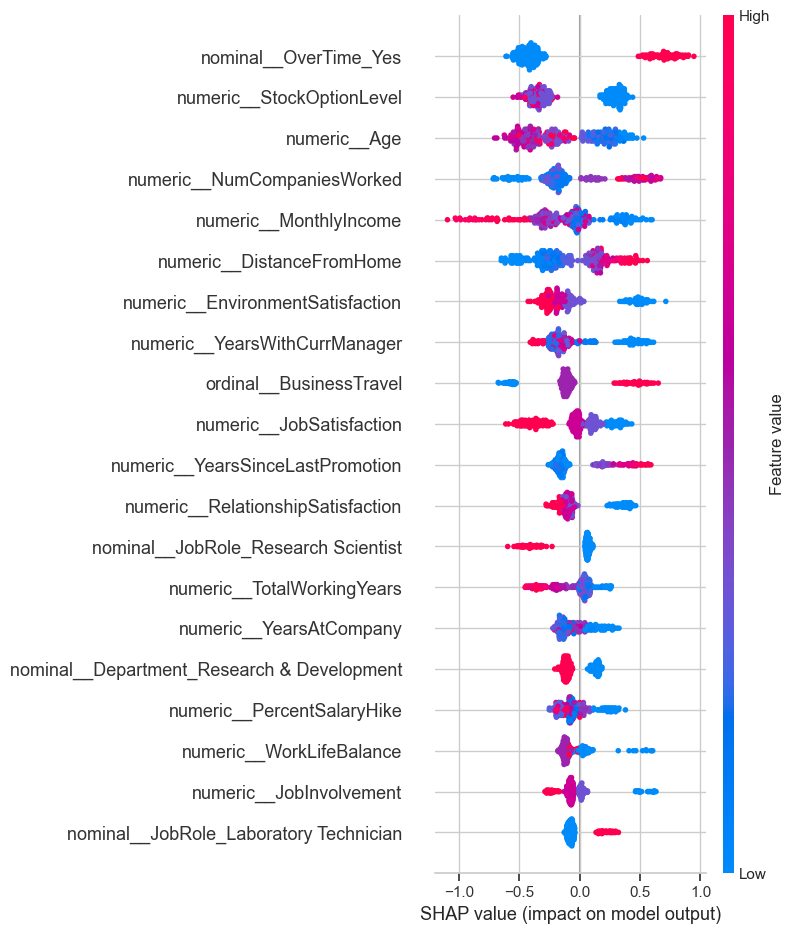

In [130]:
import shap

# Pipeline'dan sadece model adımını al
# Önce veriyi feature engineering + preprocessor'dan geçir
X_test_transformed = pipeline_xgb_final[:-1].transform(X_test)

# Feature isimlerini al
feature_names = (
    pipeline_xgb_final['preprocessor']
    .get_feature_names_out()
)

# SHAP explainer
explainer = shap.TreeExplainer(pipeline_xgb_final['model'])
shap_values = explainer.shap_values(X_test_transformed)

# Summary plot
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names)

In [131]:
# ── 1. En yüksek riskli çalışanı bul
y_test_prob_xgb = pipeline_xgb_final.predict_proba(X_test)[:, 1]
riskiest_idx = np.argmax(y_test_prob_xgb)

print(f"Çalışan index: {riskiest_idx}")
print(f"Ayrılma olasılığı: {y_test_prob_xgb[riskiest_idx]:.2%}")
print(f"Gerçekte ayrıldı mı: {'Evet' if y_test.iloc[riskiest_idx] == 1 else 'Hayır'}")
print("\nÇalışan profili:")
print(X_test.iloc[riskiest_idx])

Çalışan index: 200
Ayrılma olasılığı: 97.88%
Gerçekte ayrıldı mı: Evet

Çalışan profili:
Age                                           19
BusinessTravel                     Travel_Rarely
DailyRate                                    419
Department                                 Sales
DistanceFromHome                              21
Education                                      3
EducationField                             Other
EmployeeCount                                  1
EmployeeNumber                               959
EnvironmentSatisfaction                        4
Gender                                      Male
HourlyRate                                    37
JobInvolvement                                 2
JobLevel                                       1
JobRole                     Sales Representative
JobSatisfaction                                2
MaritalStatus                             Single
MonthlyIncome                               2121
MonthlyRate                  

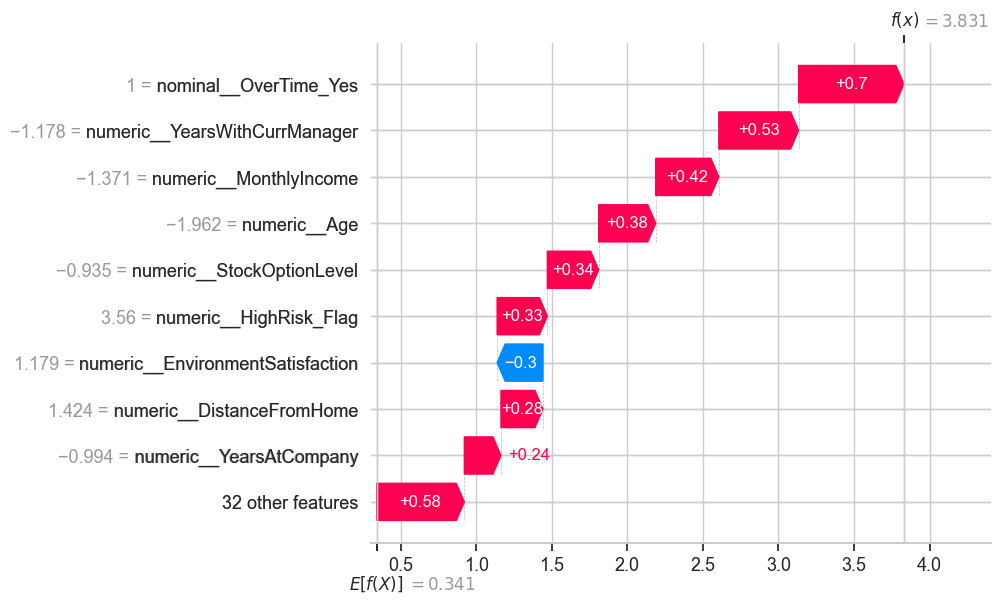

In [132]:
# ── Waterfall plot
shap_values_single = explainer.shap_values(X_test_transformed[riskiest_idx:riskiest_idx+1])

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values_single[0],
        base_values=explainer.expected_value,
        data=X_test_transformed[riskiest_idx],
        feature_names=list(feature_names)
    )
)